### **Machine Learning Pipeline**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set(style='darkgrid')

#### **Different Seed values:**

In [2]:
### set seed size list
myseed_list = [1, 7, 90, 170, 457, 3489, 5409, 6700, 9999, 10798]
myseed_len = len(myseed_list)

### function to run the pipeline repeatedly
def run_pipeline(n_runs=10):
    rmse_list = []
    r2_list = []
    seed_list = []

    for i in range(n_runs):
        # generate a new dataset each time
        myseed = myseed_list[i % myseed_len] # use the modulo operator to ensure we dont go outside bounds
        X, y = make_regression(n_samples=1000, n_features=1, noise=15, random_state=myseed)

        # define pipeline: preprocessing + model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])

        # fit the pipeline
        pipeline.fit(X, y)
        y_pred = pipeline.predict(X)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        rmse_list.append(rmse)
        r2_list.append(r2)
        seed_list.append(myseed)

        print(f'Run {i+1}: seed = {myseed}, RMSE = {rmse:.2f}, R2 = {r2:.2f}')

    return pd.DataFrame({
        'seed': seed_list,
        'RMSE': rmse_list,
        'R2': r2_list
    })

### run the pipeline 10 times and show the results
results_df = run_pipeline(n_runs=10)
results_df

Run 1: seed = 1, RMSE = 15.03, R2 = 0.86
Run 2: seed = 7, RMSE = 15.08, R2 = 0.74
Run 3: seed = 90, RMSE = 15.83, R2 = 0.97
Run 4: seed = 170, RMSE = 14.48, R2 = 0.98
Run 5: seed = 457, RMSE = 14.84, R2 = 0.95
Run 6: seed = 3489, RMSE = 15.07, R2 = 0.44
Run 7: seed = 5409, RMSE = 14.92, R2 = 0.89
Run 8: seed = 6700, RMSE = 15.43, R2 = 0.70
Run 9: seed = 9999, RMSE = 14.88, R2 = 0.65
Run 10: seed = 10798, RMSE = 14.66, R2 = 0.60


,seed,RMSE,R2
0,1,15.029712,0.862479
1,7,15.082444,0.738727
2,90,15.829503,0.973716
3,170,14.484467,0.977752
4,457,14.835233,0.945559
5,3489,15.066896,0.440097
6,5409,14.915296,0.890860
7,6700,15.431766,0.700873
8,9999,14.880444,0.647417
9,10798,14.663524,0.603243


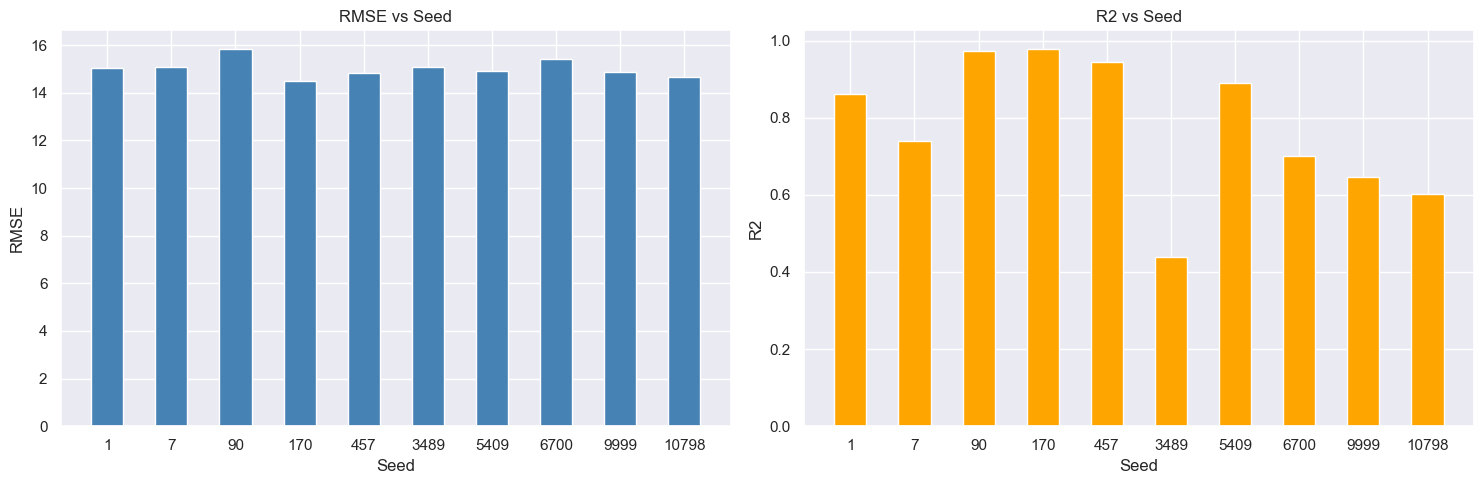

In [3]:
### visualize the results with bar charts

# convert seed to string to treat as categorical x-axis
results_df['seed'] = results_df['seed'].astype(str)

# set up subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# bar chart params
bar_width = 0.50

# plot each column
ax[0].bar(results_df['seed'], results_df['RMSE'], color='steelblue', width=bar_width)
ax[0].set_title('RMSE vs Seed')
ax[0].set_xlabel('Seed')
ax[0].set_ylabel('RMSE')

ax[1].bar(results_df['seed'], results_df['R2'], color='orange', width=bar_width)
ax[1].set_title('R2 vs Seed')
ax[1].set_xlabel('Seed')
ax[1].set_ylabel('R2')

# layout adjustment
plt.tight_layout()
plt.show()

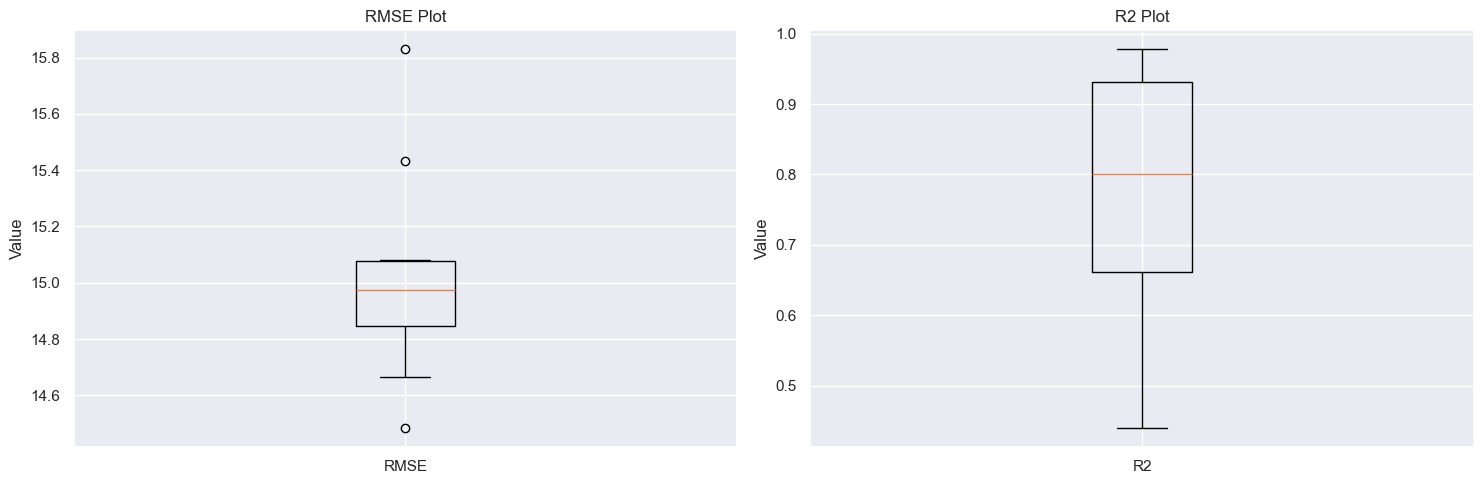

In [4]:
### visualize with boxplots
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].boxplot(results_df['RMSE'])
ax[0].set_title('RMSE Plot')
ax[0].set_ylabel('Value')
ax[0].set_xticks([1])
ax[0].set_xticklabels(['RMSE'])

ax[1].boxplot(results_df['R2'])
ax[1].set_title('R2 Plot')
ax[1].set_ylabel('Value')
ax[1].set_xticks([1])
ax[1].set_xticklabels(['R2'])

plt.tight_layout()
plt.show()

#### **Different Sample Sizes:**

In [5]:
### set sample size list
mysample_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
mysample_len = len(mysample_list)

### function to run the pipeline repeatedly
def run_pipeline(n_runs=10):
    rmse_list = []
    r2_list = []
    sample_list = []

    for i in range(n_runs):
        # generate a new dataset each time
        mysample = mysample_list[i % mysample_len] # use the modulo operator to ensure we dont go outside bounds
        X, y = make_regression(n_samples=mysample, n_features=1, noise=15, random_state=42)

        # define pipeline: preprocessing + model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])

        # fit the pipeline
        pipeline.fit(X, y)
        y_pred = pipeline.predict(X)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        rmse_list.append(rmse)
        r2_list.append(r2)
        sample_list.append(mysample)

        print(f'Run {i+1}: #samples = {mysample}, RMSE = {rmse:.2f}, R2 = {r2:.2f}')

    return pd.DataFrame({
        '#samples': sample_list,
        'RMSE': rmse_list,
        'R2': r2_list
    })

### run the pipeline 10 times and show the results
results_df = run_pipeline(n_runs=10)
results_df

Run 1: #samples = 100, RMSE = 13.25, R2 = 0.91
Run 2: #samples = 200, RMSE = 15.12, R2 = 0.97
Run 3: #samples = 300, RMSE = 15.19, R2 = 0.77
Run 4: #samples = 400, RMSE = 15.43, R2 = 0.86
Run 5: #samples = 500, RMSE = 14.90, R2 = 0.95
Run 6: #samples = 600, RMSE = 14.92, R2 = 0.68
Run 7: #samples = 700, RMSE = 14.75, R2 = 0.97
Run 8: #samples = 800, RMSE = 14.69, R2 = 0.82
Run 9: #samples = 900, RMSE = 14.46, R2 = 0.54
Run 10: #samples = 1000, RMSE = 14.85, R2 = 0.54


,#samples,RMSE,R2
0,100,13.252247,0.906945
1,200,15.121844,0.966291
2,300,15.193508,0.766825
3,400,15.433453,0.864363
4,500,14.900186,0.946205
5,600,14.916916,0.683893
6,700,14.747096,0.967265
7,800,14.685169,0.821618
8,900,14.461131,0.536519
9,1000,14.850612,0.544097


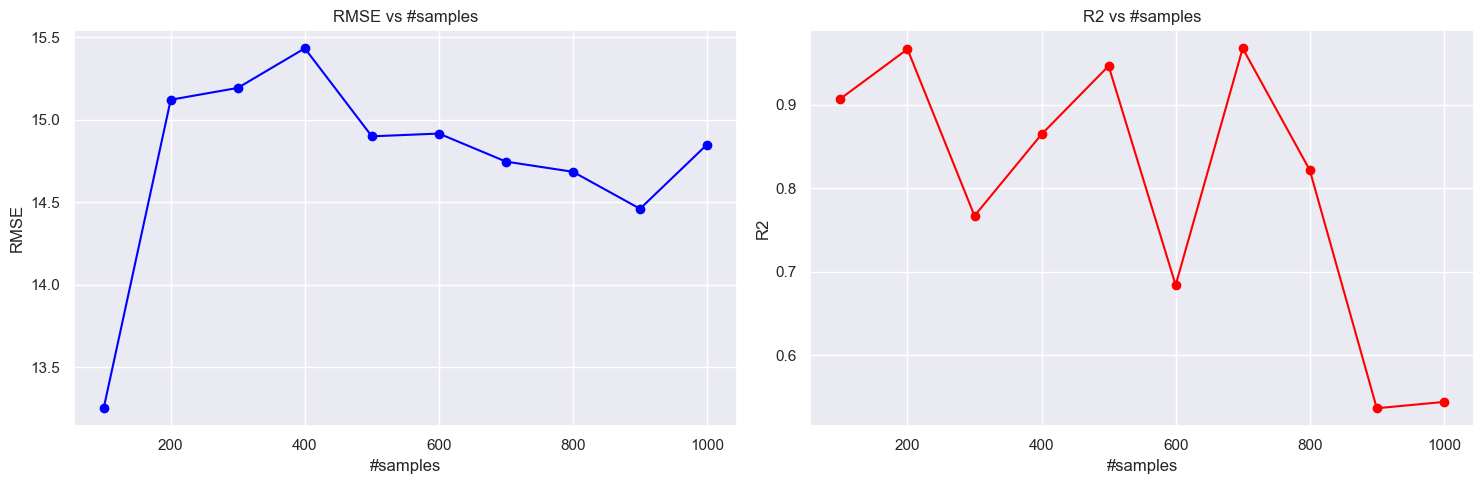

In [7]:
### visualize with line charts
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(results_df['#samples'], results_df['RMSE'], marker='o', color='blue')
ax[0].set_title('RMSE vs #samples')
ax[0].set_xlabel('#samples')
ax[0].set_ylabel('RMSE')

ax[1].plot(results_df['#samples'], results_df['R2'], marker='o', color='red')
ax[1].set_title('R2 vs #samples')
ax[1].set_xlabel('#samples')
ax[1].set_ylabel('R2')

# layout adjustment
plt.tight_layout()
plt.show()